<a href="https://colab.research.google.com/github/bforoura/GENAI26/blob/main/Module5/Tools_LangChain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LLM Tool-Calling in LangChain**

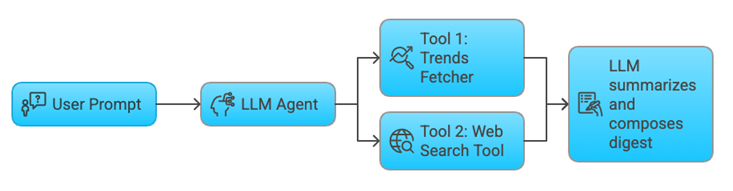
* The goal here is to demonstrate the **handshake** between an LLM and a piece of code.

* We are purposely **simulating** a **search tool** to focus on the logic of the conversation history, which consists of four critical stages:

   * **The Trigger**: The LLM receives a question it cannot answer (e.g., about fresh events in 2026) and generates a structured Tool Call instead of text.

   * **The Schema**: We define a JSON/OpenAPI schema that acts as the "user manual," teaching the model which arguments the tool requires.

  * **The Observation**: We simulate the output of a tool and wrap it in a **ToolMessage**. This represents the model "observing" the real world.

  * **The Synthesis**: We feed the entire history—the user's question, the model's request, and the tool's result—back to the LLM so it can reason through the data and provide a final answer.

In [1]:
# 1. Install dependencies
!pip install -U -q langchain-google-genai langchain


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 2.9 MB/s eta 0:00:00


In [6]:
import os
from google.colab import userdata
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, ToolMessage

# Setup Authentication and Model
os.environ["GOOGLE_API_KEY"] = userdata.get('GOOGLE_API_KEY')

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

# **Tool Schema**

* For an LLM to use a tool, it needs a **contract** that explains what the tool does and what information it requires.

* In **LangChain**, this is defined using a **JSON Schema** which is compatible with the OpenAPI specification.

* This **schema** acts as the **instruction manual** for the model's reasoning engine.

---
### **Elements of the Schema**


* **name**: The internal identifier the LLM uses to call the tool (e.g., Google Search).

* **description**: This is the most critical field for Prompt Engineering. The LLM reads this text to decide if the tool is relevant to the user's request. If the description is vague, the model might fail to trigger the tool when needed.

 * **parameters**: Defines the "shape" of the input the tool expects.

 * **type: "object"**: Indicates the arguments will be passed as key-value pairs.

* **properties**: Lists the specific arguments (like query). Each property needs its own type (e.g., string, integer) and a description so the model knows what values to generate.

 * **required**: A list of property names that the LLM must provide to successfully execute the tool.

In [7]:
# Define the Tool Schema (JSON format)
search_tool = {
    "type": "function",
    "function": {
        "name": "google_search",
        "description": "Returns information about common facts, fresh events, and news from Google Search engine.",
        "parameters": {
            "type": "object",
            "properties": {
                "query": {
                    "type": "string",
                    "description": "Search query to be sent to the search engine"
                }
            },
            "required": ["query"]
        }
    }
}

# Bind the tool to the LLM
llm_with_tools = llm.bind_tools([search_tool])


# **Manual Orchestration of an AI Agent's Brain**

1. **The Model Bind (The "Brain" Setup)**

    * Before the conversation starts, we use **llm.bind_tools()**. This doesn't run any code; it effectively "attaches" the JSON schema to the LLM's internal instructions. It tells the model: "You are no longer just a chatbot; you are a chatbot that has access to a search engine."
---
2. **Intent Recognition (The Tool Call)**

   * When we run **llm_with_tools.invoke(question)**, the LLM analyzes the prompt.
   * It realizes it doesn't have the "current" 2026 data.
   * It looks at its bound tools and finds Google Search.
   * Instead of answering the question, it returns a **Tool Call object**. This object contains the specific query it wants you to run (e.g., "current US president age").
---
3. **The Manual Observation (The Mocking)**
  * Because we aren't using an automated agent, the code pauses here.
  * We take the **tool_call_id** from the model's request. This ID is a **tracking number** that ensures the answer gets linked to the right question.
  * We create a **ToolMessage**. In our code, we "fake" the search result by writing a string of facts. In a real scenario, this is where you would call a real API and put the real results into the content field.
---
4. **Synthesis (The Final Reasoning)**
* The final invoke is the most important part of the logic. We don't just send the new search result; we send the entire history:
    
    * HumanMessage: "How old is the president?"

    * AIMessage (Tool Call): "I need to search for [X]."

    * ToolMessage (Observation): "Here is the result: [Y]."
---
* The LLM sees this full "**thought trail,**" realizes it now has all the ingredients it needs, and finally generates a natural language response: "The president is 79 years old."


---
**The "Nudge" Logic (Handling Model Quirks)**

* You'll notice a final **if not final_response.content** check in the code.
* This is a safety net for advanced models like Gemini 2.5/3.
* Sometimes, after seeing a tool result, the model generates an "**internal thought**" but stays in "**structured mode.**"
* By adding a final human nudge—"**Based on that result, answer the question**"—we force the model to **switch back to conversational mode** for the user.

In [10]:
# The Execution Flow
question = "How old is the current US president?"
print(f"USER QUESTION: {question}\n")



# --- STEP 1: AI Decides to use a tool ---
step1_response = llm_with_tools.invoke(question)

if step1_response.tool_calls:
    tool_call = step1_response.tool_calls[0]
    print(f"DEBUG: Model calling tool '{tool_call['name']}'")



    # --- STEP 2: Mock the Tool Result (Observation) ---
    mock_data = "Donald Trump is the US President. Born June 14, 1946. Today is March 2026, so he is 79."

    tool_message = ToolMessage(
        content=mock_data,
        tool_call_id=tool_call["id"]
    )



    # --- STEP 3: Final Answer Generation ---
    history = [
        HumanMessage(content=question),
        step1_response,
        tool_message
    ]

    final_response = llm_with_tools.invoke(history)

    # Logic to handle the "empty content" quirk in newer models
    if not final_response.content:
        print("DEBUG: Content was empty, sending a summary nudge...")
        # We add the model's own empty response to the history before nudging
        history.append(step1_response)
        history.append(HumanMessage(content="Based on that search result, answer the original question."))
        final_response = llm.invoke(history)

    print("\n--- FINAL RESULT ---")
    print(f"AI RESPONSE: {final_response.content}")

else:
    print(f"AI RESPONSE: {step1_response.content}")



USER QUESTION: How old is the current US president?

DEBUG: Model calling tool 'google_search'
DEBUG: Content was empty, sending a summary nudge...

--- FINAL RESULT ---
AI RESPONSE: Based on the search result:

The search result states that Donald Trump is the US President, born on June 14, 1946. It calculates his age as **79** in March 2026.

To answer how old he *is* currently (assuming the current date is not March 2026), we would calculate from his birthdate. As of late 2023/early 2024, Donald Trump is **77** years old (he turned 77 on June 14, 2023).
